In [1]:
# ============================================================
# CELL 1 - Load Data & Prepare Features
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from matplotlib import pyplot as plt

DATA_PATH = "../data/processed/modeling_data.csv"
df = pd.read_csv(DATA_PATH)

target = "co2"
features = [
    "year", "population_co2", "gdp_co2", "primary_energy_consumption_energy",
    "fossil_share_energy", "renewables_share_energy", "renewables_electricity",
    "renewables_share_elec", "solar_share_energy", "wind_share_energy",
    "hydro_share_energy", "gdp_per_capita", "energy_per_capita"
]

X = df[features]
y = df[target]

print("=" * 60)
print("REGRESSION MODELING")
print("=" * 60)
print("Features:", X.shape)
print("Target:", y.shape)
print("Total samples:", len(df))

REGRESSION MODELING
Features: (1817, 13)
Target: (1817,)
Total samples: 1817


In [2]:
# ============================================================
# CELL 2 - 70/15/15 Data Split
# ============================================================

from sklearn.model_selection import train_test_split

# Split into training (70%) and temporary data (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Divide temporary data equally into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("=" * 60)
print("DATA SPLIT")
print("=" * 60)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

DATA SPLIT
Training: (1271, 13)
Validation: (273, 13)
Testing: (273, 13)


In [3]:
# ============================================================
# CELL 3 - Initialize Regression Models
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression())
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

print("=" * 60)
print("MODEL INITIALIZATION")
print("=" * 60)

for name, model in models.items():
    print(f"{name}: initialized")

MODEL INITIALIZATION
Linear Regression: initialized
Random Forest: initialized
Gradient Boosting: initialized


In [4]:
# ============================================================
# CELL 4 - Train Regression Models
# ============================================================

print("=" * 60)
print("MODEL TRAINING")
print("=" * 60)

predictions = {}

for name, model in models.items():

    # Train each model on the same training dataset
    model.fit(X_train, y_train)

    # Generate predictions on the validation dataset
    predictions[name] = model.predict(X_val)

    print(f"{name}: trained successfully")

MODEL TRAINING
Linear Regression: trained successfully
Random Forest: trained successfully
Gradient Boosting: trained successfully


In [5]:
# ============================================================
# CELL 5 - Validation Performance
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 60)
print("VALIDATION PERFORMANCE")
print("=" * 60)

validation_results = []

for name, pred in predictions.items():

    mae = mean_absolute_error(y_val, pred)

    rmse = np.sqrt(
        mean_squared_error(y_val, pred)
    )

    r2 = r2_score(y_val, pred)

    validation_results.append([
        name, mae, rmse, r2
    ])

validation_results = pd.DataFrame(
    validation_results,
    columns=["Model", "MAE", "RMSE", "R²"]
)

validation_results = validation_results.sort_values(
    by="RMSE",
    ascending=True
)

display(validation_results.round(4))

VALIDATION PERFORMANCE


,Model,MAE,RMSE,R²
2,Gradient Boosting,20.9371,41.6238,0.9987
1,Random Forest,16.3121,60.7112,0.9973
0,Linear Regression,61.5610,101.1142,0.9925


In [6]:
# ============================================================
# CELL 6 - Select Best Model & Test Evaluation
# ============================================================

# Select the model with the lowest validation RMSE
best_model_name = validation_results.iloc[0]["Model"]
best_model = models[best_model_name]

# Evaluate the selected model on the untouched test set
test_pred = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, test_pred)

test_rmse = np.sqrt(
    mean_squared_error(y_test, test_pred)
)

test_r2 = r2_score(y_test, test_pred)

print("=" * 60)
print("FINAL TEST EVALUATION")
print("=" * 60)

print("Selected model:", best_model_name)
print("Test MAE:", round(test_mae, 4))
print("Test RMSE:", round(test_rmse, 4))
print("Test R²:", round(test_r2, 4))

FINAL TEST EVALUATION
Selected model: Gradient Boosting
Test MAE: 22.5743
Test RMSE: 68.9022
Test R²: 0.9973


TEST SET ERROR ANALYSIS

Top 10 observations by absolute error:


,country,year,actual_co2,predicted_co2,residual,absolute_error
298,China,2022,11711.808,10787.452,924.356,924.356
1732,United States,2007,6121.542,6537.526,-415.984,415.984
292,China,2016,9748.175,9962.261,-214.086,214.086
289,China,2013,9942.371,9786.452,155.919,155.919
843,Kazakhstan,2015,303.052,158.693,144.359,144.359
236,Canada,2006,566.315,460.691,105.624,105.624
277,China,2001,3724.114,3623.969,100.145,100.145
678,Indonesia,2011,500.458,403.529,96.929,96.929
711,Iran,2021,779.525,689.528,89.997,89.997
1727,United States,2002,5947.819,6037.271,-89.452,89.452



Country-wise test errors:


,observations,MAE,RMSE
country,,,
China,4,348.627,483.375
United States,5,137.052,196.337
Kazakhstan,3,90.721,99.657
Ukraine,1,60.266,60.266
Germany,6,48.628,53.966
Iran,5,42.746,51.073
Singapore,2,50.101,50.846
Indonesia,4,31.677,49.619
United Arab Emirates,3,37.587,48.347


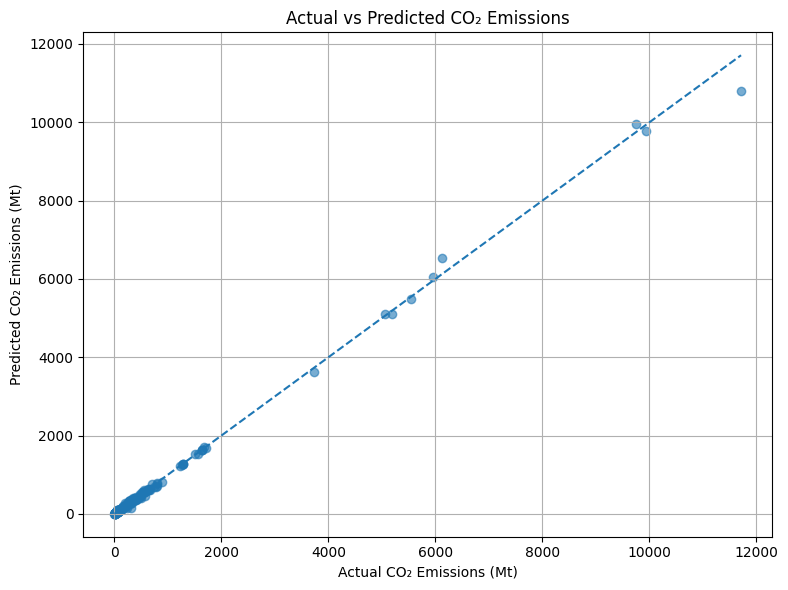

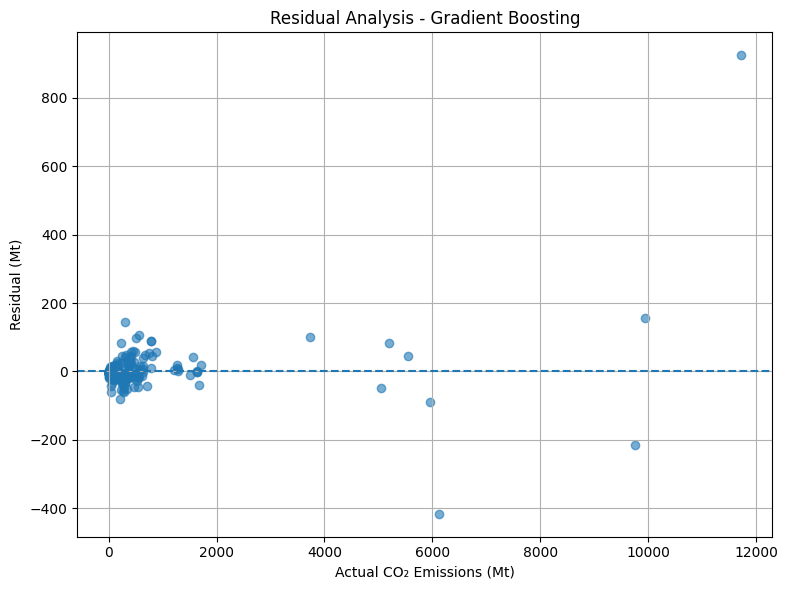

In [7]:
# ============================================================
# CELL 7 - Test Set Error Analysis
# ============================================================

# Create a dataframe containing actual and predicted values
test_analysis = df.loc[
    y_test.index, ["country", "year"]
].copy()

test_analysis["actual_co2"] = y_test
test_analysis["predicted_co2"] = test_pred

# Calculate residuals and absolute errors
test_analysis["residual"] = (
    test_analysis["actual_co2"]
    - test_analysis["predicted_co2"]
)

test_analysis["absolute_error"] = (
    test_analysis["residual"].abs()
)

print("=" * 60)
print("TEST SET ERROR ANALYSIS")
print("=" * 60)

# Display observations with the largest prediction errors
print("\nTop 10 observations by absolute error:")

display(
    test_analysis
    .sort_values("absolute_error", ascending=False)
    .head(10)
    .round(3)
)

# Calculate country-wise errors
country_error = (
    test_analysis
    .groupby("country")
    .agg(
        observations=("actual_co2", "size"),
        MAE=("absolute_error", "mean"),
        RMSE=("residual",
              lambda x: np.sqrt(np.mean(x ** 2)))
    )
    .sort_values("RMSE", ascending=False)
)

print("\nCountry-wise test errors:")

display(country_error.head(10).round(3))

# Actual vs predicted plot
plt.figure(figsize=(8, 6))

plt.scatter(
    test_analysis["actual_co2"],
    test_analysis["predicted_co2"],
    alpha=0.6
)

min_val = min(
    test_analysis["actual_co2"].min(),
    test_analysis["predicted_co2"].min()
)

max_val = max(
    test_analysis["actual_co2"].max(),
    test_analysis["predicted_co2"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual CO₂ Emissions (Mt)")
plt.ylabel("Predicted CO₂ Emissions (Mt)")
plt.title("Actual vs Predicted CO₂ Emissions")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residual plot
plt.figure(figsize=(8, 6))

plt.scatter(
    test_analysis["actual_co2"],
    test_analysis["residual"],
    alpha=0.6
)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Actual CO₂ Emissions (Mt)")
plt.ylabel("Residual (Mt)")
plt.title("Residual Analysis - Gradient Boosting")
plt.grid(True)
plt.tight_layout()
plt.show()